/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Time for unsampled data: 1.2115 seconds
Time for sampled data: 0.1435 seconds
Rand Index: 0.8281


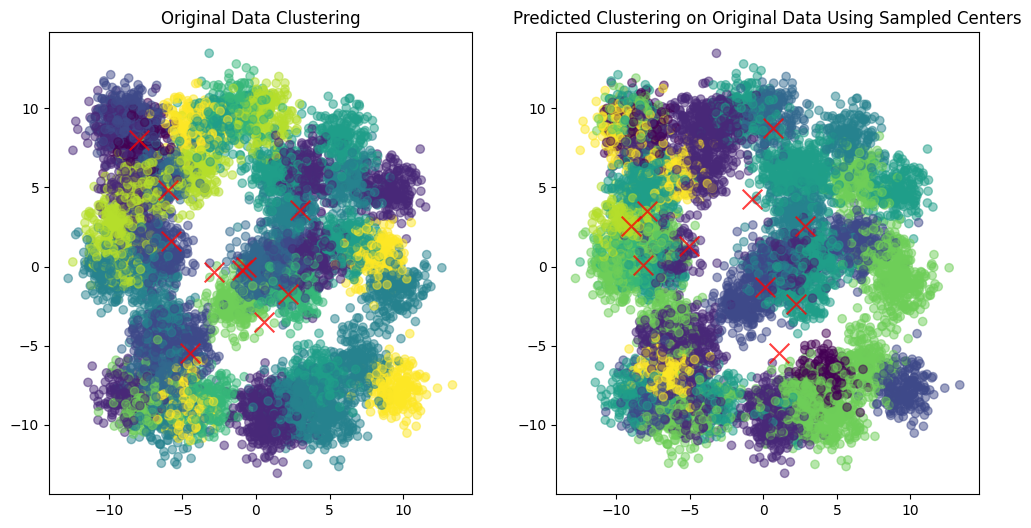

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.metrics import rand_score
from scipy.spatial.distance import cdist
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=10000, centers=50, n_features=100, random_state=42)

def norm_based_sample(percentage, data):
    norms = np.linalg.norm(data, axis=1)
    probabilities = norms / np.sum(norms)
    n_samples = int(percentage * len(data))
    indices = np.random.choice(len(data), size=n_samples, replace=False, p=probabilities)
    return data[indices]

def apply_kmeans_and_time(data, n_clusters):
    start_time = time.time()
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(data)
    elapsed_time = time.time() - start_time
    return kmeans.labels_, kmeans.cluster_centers_, elapsed_time

def predict(data, centroids):
    dist = cdist(data, centroids)
    labels = np.argmin(dist, axis=1)
    return labels

def compare_and_evaluate_clusters(original_data, original_labels, centers, sampled_labels_centers, predicted_labels):
    rand_index = rand_score(original_labels, predicted_labels)
    print(f"Rand Index: {rand_index:.4f}")
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(original_data[:, 0], original_data[:, 1], c=original_labels, cmap='viridis', alpha=0.5)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='x')
    plt.title('Original Data Clustering')

    plt.subplot(1, 2, 2)
    plt.scatter(original_data[:, 0], original_data[:, 1], c=predicted_labels, cmap='viridis', alpha=0.5)
    plt.scatter(sampled_labels_centers[:, 0], sampled_labels_centers[:, 1], c='red', s=200, alpha=0.75, marker='x')
    plt.title('Predicted Clustering on Original Data Using Sampled Centers')
    
    plt.show()

sampled_data = norm_based_sample(0.01, X)

original_labels, centers, original_time = apply_kmeans_and_time(X, 10)
sampled_labels, sampled_labels_centers, sampled_time = apply_kmeans_and_time(sampled_data, 10)

print("Time for unsampled data: {:.4f} seconds".format(original_time))
print("Time for sampled data: {:.4f} seconds".format(sampled_time))

predicted_labels = predict(X, sampled_labels_centers)

compare_and_evaluate_clusters(X, original_labels, centers, sampled_labels_centers, predicted_labels)


In [3]:
from keras.datasets import fashion_mnist

import numpy as np

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

test_images_vector = test_images.reshape(test_images.shape[0], -1)
train_images_vector = train_images.reshape(train_images.shape[0], -1)

print(np.shape(test_images_vector))
print(np.shape(train_images_vector))

2024-04-22 15:25:27.605648: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-22 15:25:28.112447: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-22 15:25:28.112541: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-22 15:25:28.178071: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-22 15:25:28.333654: I tensorflow/core/platform/cpu_feature_guar

(10000, 784)
(60000, 784)


In [4]:
sampled_data = norm_based_sample(0.01, test_images_vector)

original_labels, centers, original_time = apply_kmeans_and_time(test_images_vector, 10)
sampled_labels, sampled_labels_centers, sampled_time = apply_kmeans_and_time(sampled_data, 10)

print("Time for unsampled data: {:.4f} seconds".format(original_time))
print("Time for sampled data: {:.4f} seconds".format(sampled_time))

predicted_labels = predict(test_images_vector, sampled_labels_centers)

rand_index = rand_score(original_labels, predicted_labels)
print(f"Rand Index: {rand_index:.4f}")
    



/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Time for unsampled data: 6.7649 seconds
Time for sampled data: 0.1203 seconds
Rand Index: 0.9186


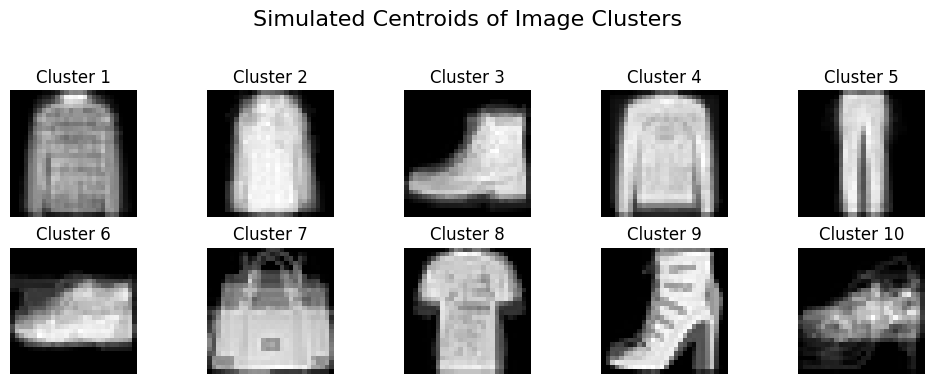

In [5]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Simulated Centroids of Image Clusters', fontsize=16)
for i, ax in enumerate(axs.flat):
    ax.imshow(sampled_labels_centers[i].reshape(28,28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
sampled_data = norm_based_sample(0.01, train_images_vector)

original_labels, centers, original_time = apply_kmeans_and_time(train_images_vector, 10)
sampled_labels, sampled_labels_centers, sampled_time = apply_kmeans_and_time(sampled_data, 10)

print("Time for unsampled data: {:.4f} seconds".format(original_time))
print("Time for sampled data: {:.4f} seconds".format(sampled_time))

predicted_labels = predict(train_images_vector, sampled_labels_centers)

rand_index = rand_score(original_labels, predicted_labels)
print(f"Rand Index: {rand_index:.4f}")

/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Time for unsampled data: 66.4098 seconds
Time for sampled data: 1.2212 seconds
Rand Index: 0.9018


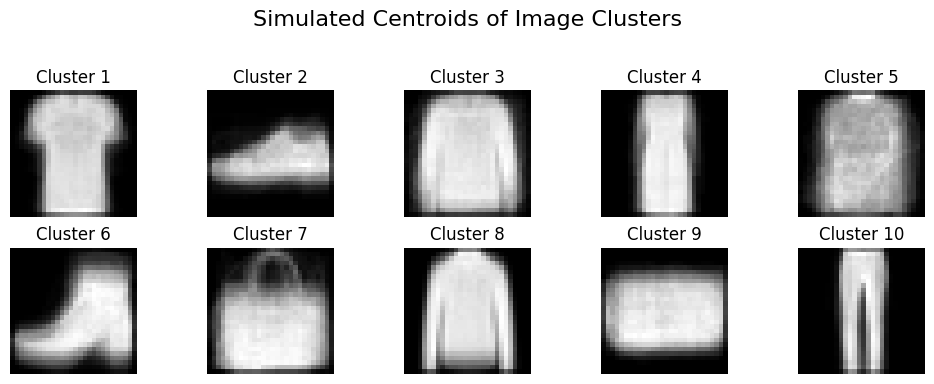

In [7]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Simulated Centroids of Image Clusters', fontsize=16)
for i, ax in enumerate(axs.flat):
    ax.imshow(sampled_labels_centers[i].reshape(28,28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [8]:
from keras.datasets import mnist

import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

test_images_vector = test_images.reshape(test_images.shape[0], -1)
train_images_vector = train_images.reshape(train_images.shape[0], -1)

print(np.shape(test_images_vector))
print(np.shape(train_images_vector))

(10000, 784)
(60000, 784)


/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Time for unsampled data: 95.3467 seconds
Time for sampled data: 1.4084 seconds
Rand Index: 0.8967


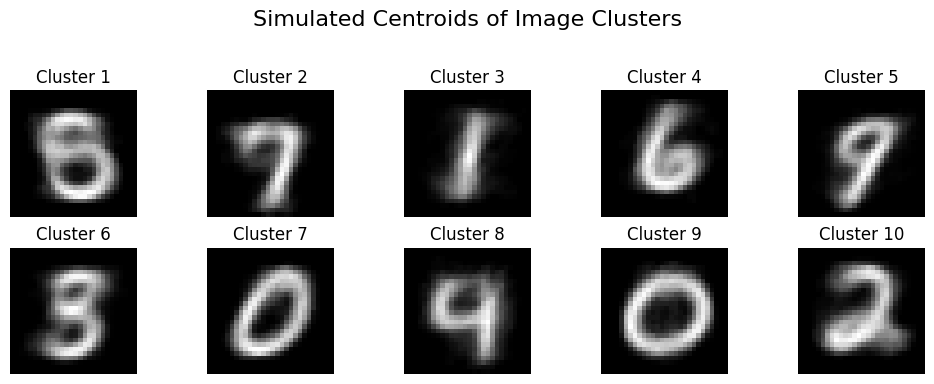

In [9]:
sampled_data = norm_based_sample(0.01, train_images_vector)

original_labels, centers, original_time = apply_kmeans_and_time(train_images_vector, 10)
sampled_labels, sampled_labels_centers, sampled_time = apply_kmeans_and_time(sampled_data, 10)

print("Time for unsampled data: {:.4f} seconds".format(original_time))
print("Time for sampled data: {:.4f} seconds".format(sampled_time))

predicted_labels = predict(train_images_vector, sampled_labels_centers)

rand_index = rand_score(original_labels, predicted_labels)
print(f"Rand Index: {rand_index:.4f}")

fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Simulated Centroids of Image Clusters', fontsize=16)
for i, ax in enumerate(axs.flat):
    ax.imshow(sampled_labels_centers[i].reshape(28,28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Time for unsampled data: 11.6451 seconds
Time for sampled data: 0.1442 seconds
Rand Index: 0.8572


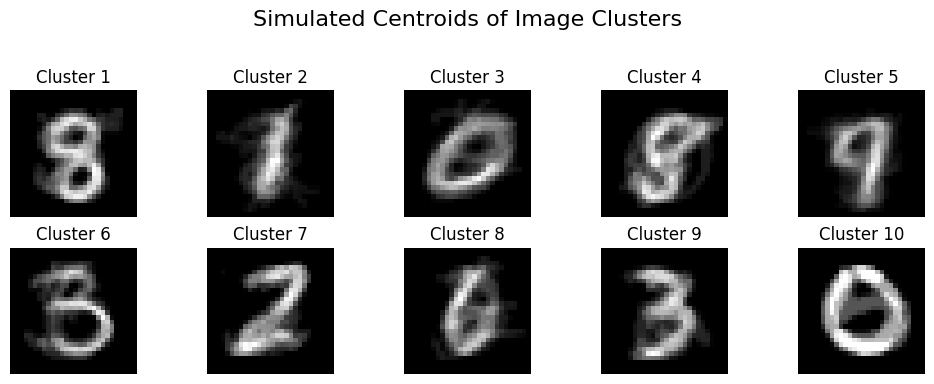

In [10]:
sampled_data = norm_based_sample(0.01, test_images_vector)

original_labels, centers, original_time = apply_kmeans_and_time(test_images_vector, 10)
sampled_labels, sampled_labels_centers, sampled_time = apply_kmeans_and_time(sampled_data, 10)

print("Time for unsampled data: {:.4f} seconds".format(original_time))
print("Time for sampled data: {:.4f} seconds".format(sampled_time))

predicted_labels = predict(test_images_vector, sampled_labels_centers)

rand_index = rand_score(original_labels, predicted_labels)
print(f"Rand Index: {rand_index:.4f}")
    
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Simulated Centroids of Image Clusters', fontsize=16)
for i, ax in enumerate(axs.flat):
    ax.imshow(sampled_labels_centers[i].reshape(28,28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [11]:
import pandas as pd
traindata = pd.DataFrame(pd.read_csv("/home/manavparmar/Desktop/data science project/data/bio_train.dat", sep="\t", header=None))
traindata = traindata.dropna()
traindata = traindata.drop_duplicates()
print(traindata.shape)
traindata = traindata[:10000]

(145751, 77)


In [12]:
traindata.shape
traindata = np.array(traindata)

In [13]:
def kmeans_cost(data, centers, labels):
    cost = 0.0
    for i in range(len(data)):
        distance = np.linalg.norm(data[i] - centers[labels[i]]) ** 2
        cost += distance
    return cost

print(type(traindata))
traindata = np.array(traindata)

<class 'numpy.ndarray'>


In [14]:
coreset_size = [500, 1000, 2000, 5000, 7000, 10000]

kmeans = KMeans(n_clusters=50, init='k-means++', random_state=42).fit(traindata)
centers = kmeans.cluster_centers_
cost = kmeans_cost(traindata, centers, kmeans.labels_)
optimal_labels = kmeans.labels_
print(f'Cost of KMeans: {cost}')

/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cost of KMeans: 20240766450.872005


In [20]:
from sklearn.cluster import KMeans
results = []

In [21]:
for size in coreset_size:
    avg_cost = 0
    start_time = time.time()
    rand_ind = 0

    for _ in range(5):
        sampled_data = norm_based_sample(size/10000, traindata)
        kmeans = KMeans(n_clusters = 50, init = 'k-means++').fit(sampled_data)
        labels = kmeans.predict(traindata)
        centers = kmeans.cluster_centers_
        avg_cost += kmeans_cost(traindata, centers, labels)
        rand_ind += rand_score(optimal_labels,labels)

    rand_ind /= 5
    end_time = time.time()
    avg_cost /= 5
    reduction = ((len(traindata) - len(sampled_data)) / len(traindata)) * 100
    error = (abs(avg_cost - cost)/cost) * 100
    results.append({'Sampling Type': 'Norm Based Sampling',
                            'Coreset Size': size,
                            'Average Cost': avg_cost,
                            'Reduction in Data Size': reduction,
                            'Error': error,
                            'Avg Rand Index': rand_ind,
                            'Data': 'KDD',
                            'Optimal Cost': cost,
                            'Avg Time': (end_time - start_time)/5
                        })

/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will chang

In [22]:
results_df = pd.DataFrame(results)
results_df


,Sampling Type,Coreset Size,Average Cost,Reduction in Data Size,Error,Avg Rand Index,Data,Optimal Cost,Avg Time
0,Norm Based Sampling,500,5.226550e+10,95.0,158.218985,0.976708,KDD,2.024077e+10,0.917636
1,Norm Based Sampling,1000,4.398408e+10,90.0,117.304431,0.978205,KDD,2.024077e+10,1.853454
2,Norm Based Sampling,2000,4.307604e+10,80.0,112.818216,0.980376,KDD,2.024077e+10,1.972131
3,Norm Based Sampling,5000,2.856856e+10,50.0,41.143660,0.984855,KDD,2.024077e+10,2.720586
4,Norm Based Sampling,7000,2.738105e+10,30.0,35.276736,0.984289,KDD,2.024077e+10,2.904909
5,Norm Based Sampling,10000,2.038681e+10,0.0,0.721515,0.989846,KDD,2.024077e+10,3.191688


In [30]:
print("Average error: ", results_df["Error"].mean())
print("Average rand score: ", results_df["Avg Rand Index"].mean())
print("Average cost: ", results_df["Average Cost"].mean())
print("Average time: ", results_df["Avg Time"].mean())

Average error:  77.58059030612877
Average rand score:  0.9823798753208655
Average cost:  35943672545.943375
Average time:  2.260067415237427


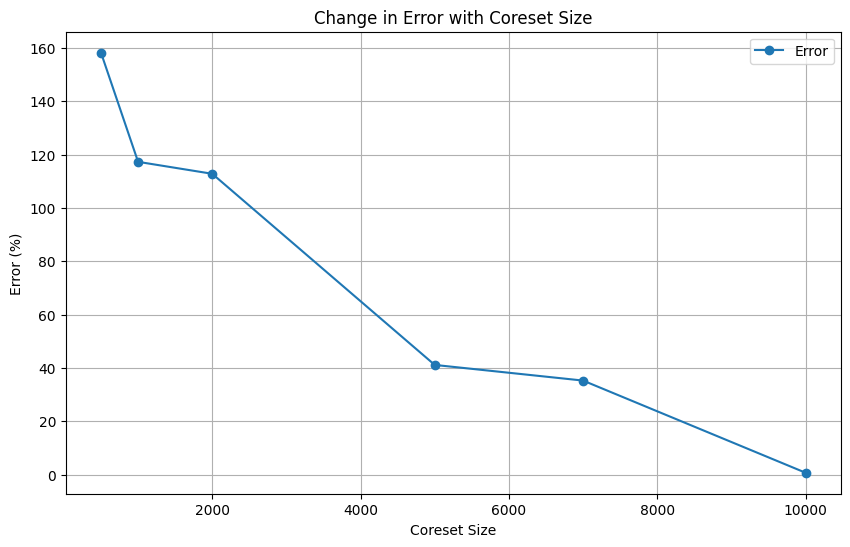

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Error'], marker='o', linestyle='-', label='Error')
plt.legend()
plt.title('Change in Error with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error (%)')
plt.grid(True)
plt.show()

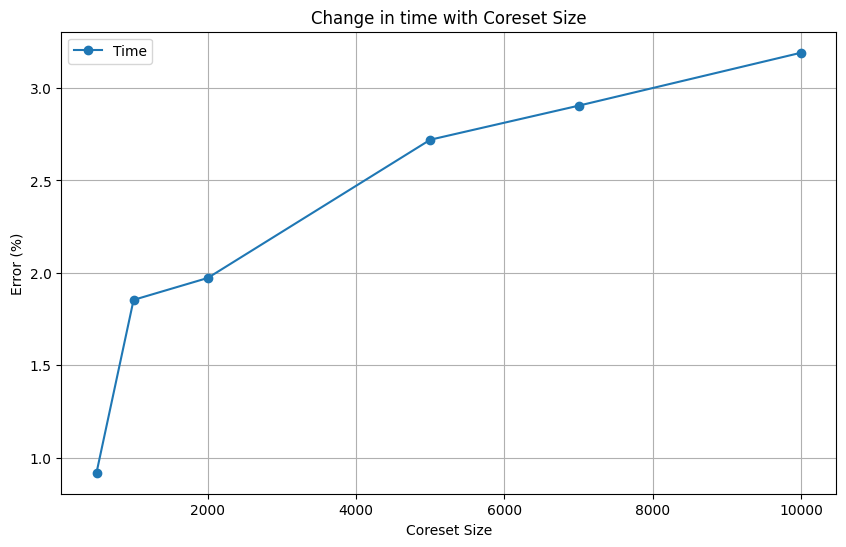

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error (%)')
plt.grid(True)
plt.show()

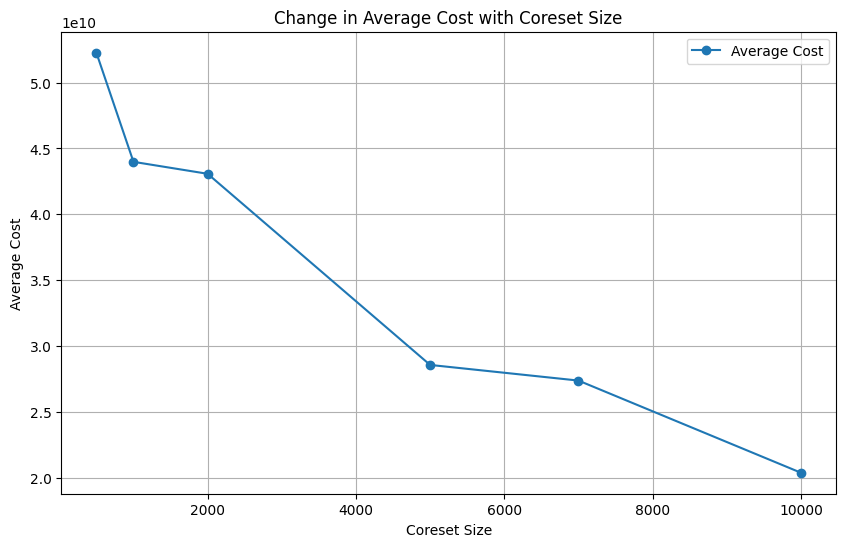

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Average Cost'], marker='o', linestyle='-', label='Average Cost')
plt.legend()
plt.title('Change in Average Cost with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Cost')
plt.grid(True)
plt.show()

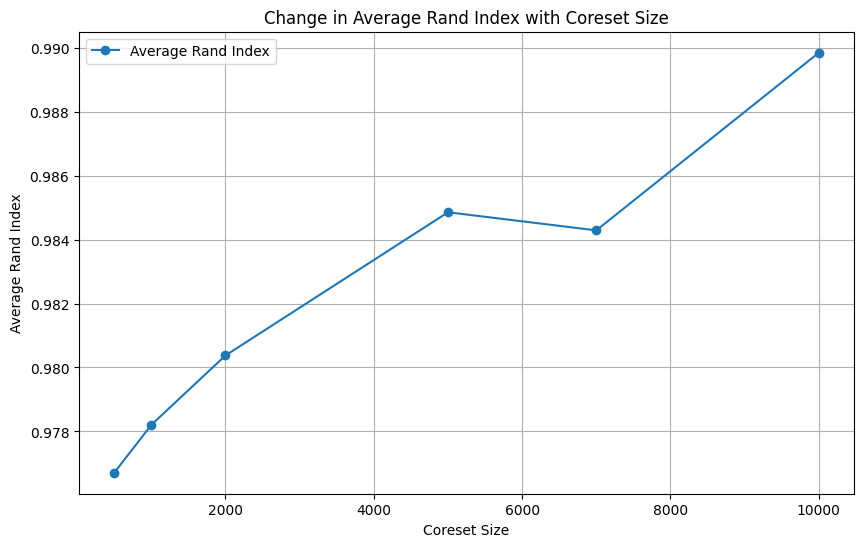

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Rand Index'], marker='o', linestyle='-', label='Average Rand Index')
plt.legend()
plt.title('Change in Average Rand Index with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Rand Index')
plt.grid(True)
plt.show()

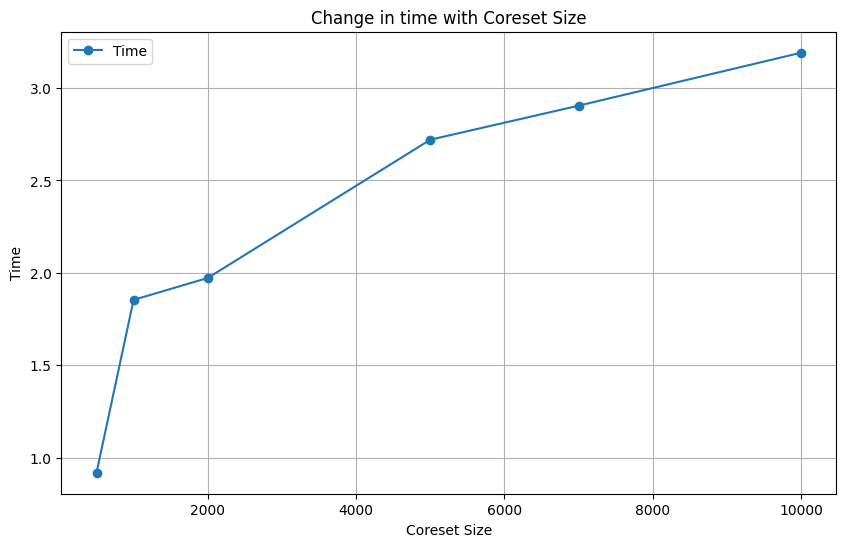

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Time')
plt.grid(True)
plt.show()